In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy

In [2]:
df = allanself.process_data('data/0009+081_dem.txt')
(df['RAcosDEC']/1000).describe()

count    12.000000
mean      0.067841
std       1.170525
min      -2.410913
25%      -0.330764
50%       0.016991
75%       0.457381
max       2.544614
Name: RAcosDEC, dtype: float64

In [3]:
df['Dec. (mas)'].describe()

count    12.000000
mean      0.072218
std       1.165093
min      -1.775498
25%      -0.462697
50%       0.115951
75%       0.521750
max       2.331500
Name: Dec. (mas), dtype: float64

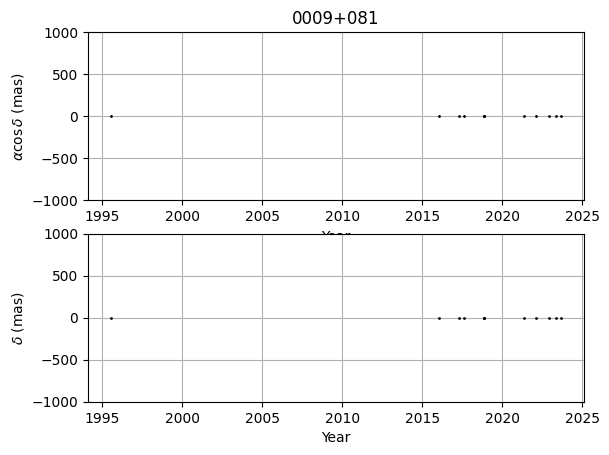

In [4]:
plt.subplot(211)
plt.title('0009+081')
plt.errorbar(df['BY'], df['RAcosDEC']/1000,yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [5]:
df_ra = allanself.remove_outliers(df,'RA')
df_dec= allanself.remove_outliers(df,'DEC')

c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\20 Samples\allanself.py:64: RuntimeWarning: invalid value encountered in scalar divide
  return sum(w[i]*(y[i]-ywbar)**2 for i in range(N))/((1-1/Np)*sum(w[i] for i in range(N)))
c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\20 Samples\allanself.py:64: RuntimeWarning: invalid value encountered in scalar divide
  return sum(w[i]*(y[i]-ywbar)**2 for i in range(N))/((1-1/Np)*sum(w[i] for i in range(N)))


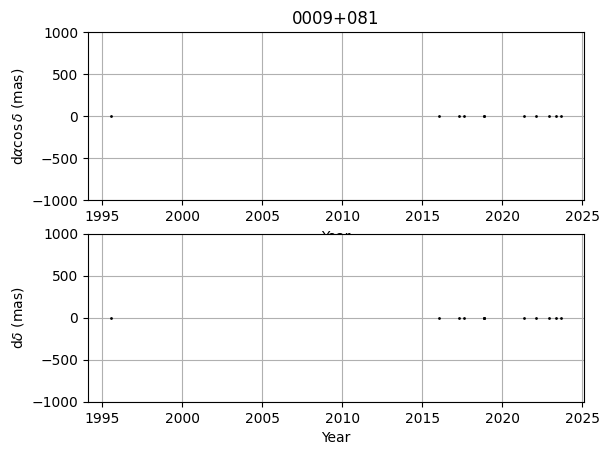

In [6]:
plt.subplot(211)
plt.title('0009+081')
plt.errorbar(df_ra['BY'], df_ra['RAcosDEC']/1000,yerr=df_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_dec['BY'], df_dec['Dec. (micas)']/1000, yerr=df_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

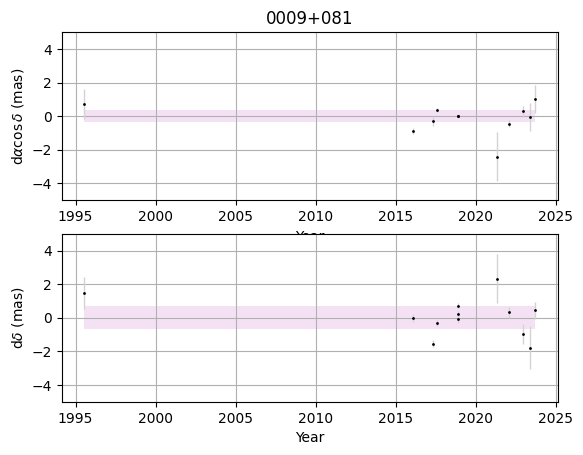

In [7]:
radec_std = np.sqrt(allanself.wvar(df_ra['RAcosDEC'].values/1000,1/(df_ra['Err. R.A. (micas)'].values/1000)**2))
dec_std = np.sqrt(allanself.wvar(df_dec['Dec. (micas)'].values/1000,1/(df_dec['Err. Dec. (micas)'].values/1000)**2))
plt.subplot(211)
plt.title('0009+081')
plt.errorbar(df_ra['BY'], df_ra['RAcosDEC']/1000,yerr=df_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.fill_between(df_ra['BY'], (-radec_std), (radec_std), facecolor='plum', alpha=0.3)
plt.ylim(-5,5)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_dec['BY'], df_dec['Dec. (micas)']/1000, yerr=df_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.fill_between(df_dec['BY'], (-dec_std), (dec_std), facecolor='plum', alpha=0.3)
plt.ylim(-5,5)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

In [10]:
tau_dec, allanstd_dec = allanself.oadev(df_dec['Dec. (micas)'].values,df_dec['MJD'].values,df_dec['Err. Dec. (micas)'].values)
tau_ra, allanstd_ra = allanself.oadev(df_ra['RAcosDEC'].values,df_ra['MJD'].values,df_ra['Err. R.A. (micas)'].values)
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_low, ci_dec_high = allanself.confidence_int(df_dec['Dec. (micas)'].values,df_dec['Err. Dec. (micas)'].values,allanstd_dec,modified=False,overlapping=True,devtype='allan')
ci_ra_low, ci_ra_high = allanself.confidence_int(df_ra['RAcosDEC'].values,df_ra['Err. R.A. (micas)'].values,allanstd_ra,modified=False,overlapping=True,devtype='allan')
tau_dec_year = np.array([x/365.242198781 for x in tau_dec])
tau_ra_year = np.array([x/365.242198781 for x in tau_ra])

C:\Users\Davendra\AppData\Local\Temp\ipykernel_21392\559402244.py:3: RuntimeWarning: divide by zero encountered in log10
  slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
C:\Users\Davendra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:1448: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
C:\Users\Davendra\AppData\Local\Temp\ipykernel_21392\559402244.py:16: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


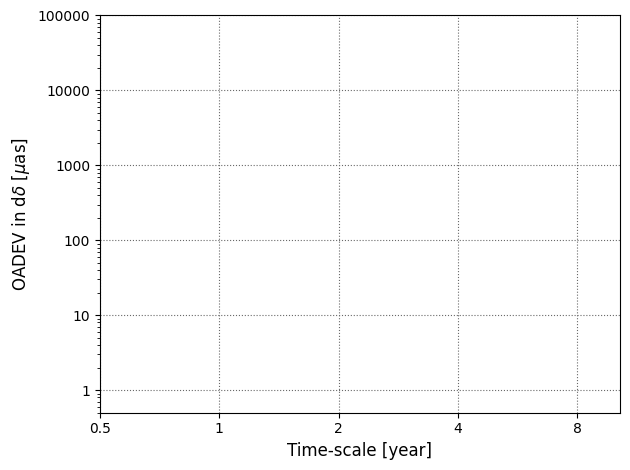

In [11]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (-0.25 <= slopes_dec) & (slopes_dec <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dec_year[1:], 0.1, 10**5, where= (slopes_dec > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dec_year, ci_dec_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dec_year, ci_dec_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**5)
plt.xlim(0.5,max(tau_dec_year))
plt.tight_layout()